In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = True
load_npz_for_analysis = True


# ----------------------------------------------------------
# Outer sweep
# Can be ANY sweep:
# current, IF, pulse length, amplitude, etc.
# ----------------------------------------------------------

IF_sweep = np.linspace(start=-100e6, stop=0e6, num=121) #np.linspace(start=60e6, stop=140e6, num=121)

lo = 3.676e9 + 50e6 - 800e6  # Hz


batches = [
    # {
    #     "date": "2026-08-08",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
    #     "time": ((11, 58), (12, 1)),
    #     "sweep": current_A_print,
    # },
    {
        "date": "2026-08-10",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-10",
        "time": ((18, 57), (21, 50)),
        "sweep": IF_sweep,
    },
]


# ----------------------------------------------------------
# HDF5 settings
# ----------------------------------------------------------

file_key = "CavitySWAP1D_len_loop"

plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None               # None -> auto-choose inner sweep axis
subtract_mean = True


# ----------------------------------------------------------
# Axis information
# ----------------------------------------------------------

x_label = "snail_freq"
y_label = "len"


# ----------------------------------------------------------
# Plot conversion
#
# plotted_x = (raw_x + x_offset) * x_scale
# plotted_y = (raw_y + y_offset) * y_scale
#
# Examples:
#
# IF -> absolute frequency in GHz:
#     x_offset = lo
#     x_scale = 1e-9
#
# Current A -> mA:
#     x_offset = 0
#     x_scale = 1e3
#
# Hz -> MHz:
#     x_scale = 1e-6
#
# seconds -> ns:
#     y_scale = 1e9
# ----------------------------------------------------------

x_offset = lo
x_scale = 1e-9

y_offset = 0.0
y_scale = 1.0

x_plot_label = "SNAIL FREQ (GHz)"
y_plot_label = "len (ns)"


# ----------------------------------------------------------
# Output
# ----------------------------------------------------------

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
)

os.makedirs(output_folder, exist_ok=True)


# ==========================================================
# GENERATE OUTPUT FILENAME
# ==========================================================

st_d = batches[0]["date"].replace("-", "")
end_d = batches[-1]["date"].replace("-", "")

st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]

save_npz_name = (
    f"{file_key}_"
    f"{st_d}_{st_h:02d}{st_m:02d}_"
    f"to_"
    f"{end_d}_{end_h:02d}{end_m:02d}_"
    f"{plot_data}.npz"
)

npz_path = os.path.join(
    output_folder,
    save_npz_name,
)


# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    """
    Extract (hour, minute) from filename.

    Assumes filename begins something like:
        16-34-...
    """
    try:
        parts = os.path.basename(filename).split("-")
        return int(parts[0]), int(parts[1])

    except Exception:
        return -1, -1


def get_filtered_files(
    folder,
    start_time,
    end_time,
    file_key,
):
    """
    Return HDF5 files containing file_key
    and lying inside the requested time range.
    """

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".hdf5") and file_key in f
    ]

    files = [
        f
        for f in files
        if start_time <= extract_time(f) <= end_time
    ]

    return sorted(files)


def load_one_hdf5(
    filename,
    y_key=None,
    subtract_mean=True,
):
    """
    Load one HDF5 file.

    Returns:
        key
        y_vals
        I_val
        Q_val
        mag_val
    """

    with h5py.File(filename, "r") as f:

        # Automatically choose the inner sweep axis
        # if y_key is not specified.
        key = y_key or next(
            k
            for k in f.keys()
            if k not in {"I", "Q", "Magnitude"}
        )

        y_vals = np.asarray(f[key][()])

        # Average repeated measurements if needed
        if f["I"].ndim > 1:
            I_val = np.mean(f["I"][()], axis=0)
        else:
            I_val = np.asarray(f["I"][()])

        if f["Q"].ndim > 1:
            Q_val = np.mean(f["Q"][()], axis=0)
        else:
            Q_val = np.asarray(f["Q"][()])

        # Magnitude
        if "Magnitude" in f.keys():

            if f["Magnitude"].ndim > 1:
                mag_val = np.mean(
                    f["Magnitude"][()],
                    axis=0,
                )
            else:
                mag_val = np.asarray(
                    f["Magnitude"][()]
                )

        else:
            mag_val = np.sqrt(
                I_val**2 + Q_val**2
            )

        # Remove mean independently for each trace
        if subtract_mean:
            I_val = I_val - np.mean(I_val)
            Q_val = Q_val - np.mean(Q_val)
            mag_val = mag_val - np.mean(mag_val)

    return (
        key,
        y_vals,
        I_val,
        Q_val,
        mag_val,
    )


def base_mesh_plot(
    x,
    y,
    z,
    x_offset=0.0,
    x_scale=1.0,
    y_offset=0.0,
    y_scale=1.0,
    x_plot_label="x",
    y_plot_label="y",
    plot_data="MAG",
    x_label="x",
    y_label="y",
    title_suffix="",
):
    """
    Generic 2D mesh plotting function.

    Conversion:
        plotted_x = (x + x_offset) * x_scale
        plotted_y = (y + y_offset) * y_scale
    """

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    x_plot = (x + x_offset) * x_scale
    y_plot = (y + y_offset) * y_scale

    plt.figure(figsize=(9, 6))

    plt.pcolormesh(
        x_plot,
        y_plot,
        z.T,
        shading="auto",
        cmap="viridis",
    )

    plt.xlabel(x_plot_label)
    plt.ylabel(y_plot_label)

    title = (
        f"{plot_data}: "
        f"{x_label} vs {y_label}"
    )

    if title_suffix:
        title += f" {title_suffix}"

    plt.title(title)

    plt.colorbar(
        label=plot_data
    )

    plt.tight_layout()


# ==========================================================
# PROCESS HDF5 -> NPZ
# ==========================================================

if build_npz_from_hdf5:

    grouped_files = []
    x_values = []

    file_dates = []
    file_times = []

    # ------------------------------------------------------
    # Collect files and corresponding outer-sweep values
    # ------------------------------------------------------

    for b in batches:

        files = get_filtered_files(
            folder=b["folder"],
            start_time=b["time"][0],
            end_time=b["time"][1],
            file_key=file_key,
        )

        sweep = np.asarray(
            b["sweep"]
        )

        n = min(
            len(files),
            len(sweep),
        )

        print(
            f'\nBatch {b["date"]}:'
        )

        print(
            f"  Files found: {len(files)}"
        )

        print(
            f"  Sweep points: {len(sweep)}"
        )

        if len(files) != len(sweep):
            print(
                "  WARNING: number of files "
                "does not match number of sweep points."
            )

            print(
                f"  Using first {n} points."
            )

        grouped_files.extend(
            files[:n]
        )

        x_values.extend(
            sweep[:n]
        )

        file_dates.extend(
            [b["date"]] * n
        )

        file_times.extend(
            [
                extract_time(f)
                for f in files[:n]
            ]
        )


    if not grouped_files:
        raise ValueError(
            "No matching HDF5 files found."
        )


    x_values = np.asarray(
        x_values
    )


    # ------------------------------------------------------
    # Load HDF5 data
    # ------------------------------------------------------

    I_2d = []
    Q_2d = []
    MAG_2d = []

    sweep_axis = []

    key = None


    for i, fname in enumerate(grouped_files):

        (
            key,
            y_vals,
            I_v,
            Q_v,
            M_v,
        ) = load_one_hdf5(
            filename=fname,
            y_key=y_key,
            subtract_mean=subtract_mean,
        )

        sweep_axis.append(
            y_vals
        )

        I_2d.append(
            I_v
        )

        Q_2d.append(
            Q_v
        )

        MAG_2d.append(
            M_v
        )


    sweep_axis = np.asarray(
        sweep_axis
    )

    I_2d = np.asarray(
        I_2d
    )

    Q_2d = np.asarray(
        Q_2d
    )

    MAG_2d = np.asarray(
        MAG_2d
    )


    # Assume each HDF5 file uses the same inner sweep
    y_values = sweep_axis[0]


    # ------------------------------------------------------
    # Check dimensions
    # ------------------------------------------------------

    print("\nFinal dataset:")

    print(
        f"  x_values shape: {x_values.shape}"
    )

    print(
        f"  y_values shape: {y_values.shape}"
    )

    print(
        f"  I shape: {I_2d.shape}"
    )

    print(
        f"  Q shape: {Q_2d.shape}"
    )

    print(
        f"  MAG shape: {MAG_2d.shape}"
    )

    print(
        f"  y_key: {key}"
    )


    if I_2d.shape != (
        len(x_values),
        len(y_values),
    ):
        print(
            "\nWARNING:"
            " Data dimensions do not match "
            "(outer sweep, inner sweep)."
        )


    # ------------------------------------------------------
    # Save NPZ
    # ------------------------------------------------------

    np.savez_compressed(

        npz_path,

        # ------------------------------
        # Generic axes
        # ------------------------------

        x_values=x_values,
        y_values=y_values,

        # Full inner sweep axis
        # for every outer sweep point
        sweep_axis=sweep_axis,


        # ------------------------------
        # Measurement data
        # ------------------------------

        I=I_2d,
        Q=Q_2d,
        MAG=MAG_2d,


        # ------------------------------
        # Axis metadata
        # ------------------------------

        x_label=x_label,
        y_label=y_label,
        y_key=key,

        x_offset=x_offset,
        x_scale=x_scale,

        y_offset=y_offset,
        y_scale=y_scale,

        x_plot_label=x_plot_label,
        y_plot_label=y_plot_label,


        # ------------------------------
        # File metadata
        # ------------------------------

        filenames=np.asarray(
            grouped_files,
            dtype=object,
        ),

        file_dates=np.asarray(
            file_dates,
            dtype=object,
        ),

        file_times=np.asarray(
            file_times,
            dtype=object,
        ),


        # ------------------------------
        # Batch metadata
        # ------------------------------

        batch_dates=np.asarray(
            [b["date"] for b in batches],
            dtype=object,
        ),

        batch_start_times=np.asarray(
            [b["time"][0] for b in batches],
            dtype=object,
        ),

        batch_end_times=np.asarray(
            [b["time"][1] for b in batches],
            dtype=object,
        ),

        batch_folders=np.asarray(
            [b["folder"] for b in batches],
            dtype=object,
        ),


        # ------------------------------
        # Other settings
        # ------------------------------

        file_key=file_key,
        subtract_mean=subtract_mean,
        plot_data_saved=plot_data,
    )


    print(
        f"\nSaved main NPZ to:\n{npz_path}"
    )


# ==========================================================
# ANALYSIS
# ==========================================================

if load_npz_for_analysis:

    data = np.load(
        npz_path,
        allow_pickle=True,
    )


    # ------------------------------------------------------
    # Load data
    # ------------------------------------------------------

    x_values = data["x_values"]
    y_values = data["y_values"]

    data_2d = data[plot_data]


    # ------------------------------------------------------
    # Load plotting information from NPZ
    # ------------------------------------------------------

    saved_x_offset = float(
        data["x_offset"]
    )

    saved_x_scale = float(
        data["x_scale"]
    )

    saved_y_offset = float(
        data["y_offset"]
    )

    saved_y_scale = float(
        data["y_scale"]
    )

    saved_x_plot_label = str(
        data["x_plot_label"]
    )

    saved_y_plot_label = str(
        data["y_plot_label"]
    )

    saved_x_label = str(
        data["x_label"]
    )

    saved_y_label = str(
        data["y_label"]
    )


    # ------------------------------------------------------
    # Raw 2D mesh plot
    # ------------------------------------------------------

    base_mesh_plot(
        x=x_values,
        y=y_values,
        z=data_2d,

        x_offset=saved_x_offset,
        x_scale=saved_x_scale,

        y_offset=saved_y_offset,
        y_scale=saved_y_scale,

        x_plot_label=saved_x_plot_label,
        y_plot_label=saved_y_plot_label,

        plot_data=plot_data,

        x_label=saved_x_label,
        y_label=saved_y_label,
    )

    plt.show()


Batch 2026-08-10:
  Files found: 121
  Sweep points: 121



Batch 2026-08-10:
  Files found: 121
  Sweep points: 121

Final dataset:
  x_values shape: (121,)
  y_values shape: (100,)
  I shape: (121, 100)
  Q shape: (121, 100)
  MAG shape: (121, 100)
  y_key: length_snail

Saved main NPZ to:
C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySWAP1D_len_loop_20260810_1803_to_20260810_1849_MAG.npz


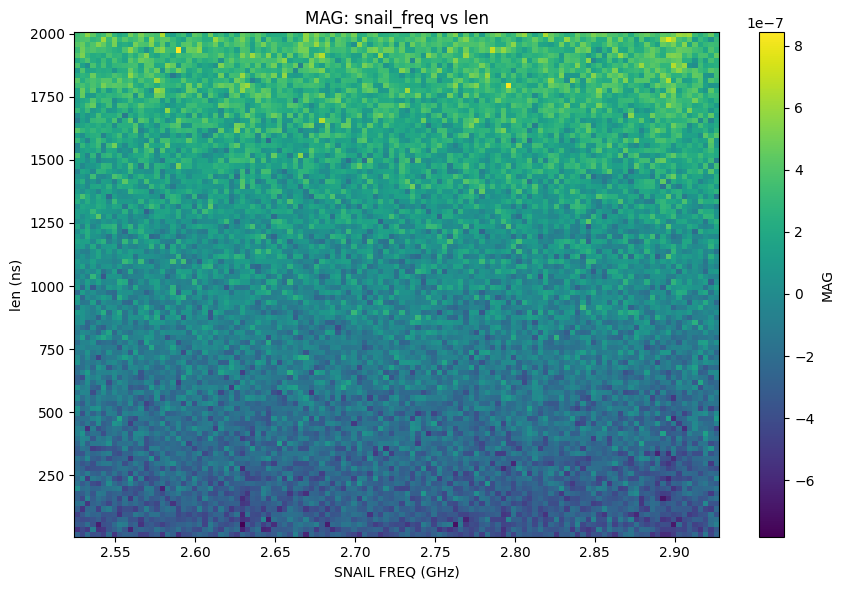

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = True
load_npz_for_analysis = True


# ----------------------------------------------------------
# Outer sweep
# Can be ANY sweep:
# current, IF, pulse length, amplitude, etc.
# ----------------------------------------------------------

IF_sweep = np.linspace(start=-400e6, stop=0e6, num=121)

lo = 3.676e9 + 50e6 - 800e6  # Hz


batches = [
    # {
    #     "date": "2026-08-08",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
    #     "time": ((11, 58), (12, 1)),
    #     "sweep": current_A_print,
    # },
    {
        "date": "2026-08-10",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-10",
        "time": ((18, 3), (18, 49)),
        "sweep": IF_sweep,
    },
]


# ----------------------------------------------------------
# HDF5 settings
# ----------------------------------------------------------

file_key = "CavitySWAP1D_len_loop"

plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None               # None -> auto-choose inner sweep axis
subtract_mean = True


# ----------------------------------------------------------
# Axis information
# ----------------------------------------------------------

x_label = "snail_freq"
y_label = "len"


# ----------------------------------------------------------
# Plot conversion
#
# plotted_x = (raw_x + x_offset) * x_scale
# plotted_y = (raw_y + y_offset) * y_scale
#
# Examples:
#
# IF -> absolute frequency in GHz:
#     x_offset = lo
#     x_scale = 1e-9
#
# Current A -> mA:
#     x_offset = 0
#     x_scale = 1e3
#
# Hz -> MHz:
#     x_scale = 1e-6
#
# seconds -> ns:
#     y_scale = 1e9
# ----------------------------------------------------------

x_offset = lo
x_scale = 1e-9

y_offset = 0.0
y_scale = 1.0

x_plot_label = "SNAIL FREQ (GHz)"
y_plot_label = "len (ns)"


# ----------------------------------------------------------
# Output
# ----------------------------------------------------------

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
)

os.makedirs(output_folder, exist_ok=True)


# ==========================================================
# GENERATE OUTPUT FILENAME
# ==========================================================

st_d = batches[0]["date"].replace("-", "")
end_d = batches[-1]["date"].replace("-", "")

st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]

save_npz_name = (
    f"{file_key}_"
    f"{st_d}_{st_h:02d}{st_m:02d}_"
    f"to_"
    f"{end_d}_{end_h:02d}{end_m:02d}_"
    f"{plot_data}.npz"
)

npz_path = os.path.join(
    output_folder,
    save_npz_name,
)


# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    """
    Extract (hour, minute) from filename.

    Assumes filename begins something like:
        16-34-...
    """
    try:
        parts = os.path.basename(filename).split("-")
        return int(parts[0]), int(parts[1])

    except Exception:
        return -1, -1


def get_filtered_files(
    folder,
    start_time,
    end_time,
    file_key,
):
    """
    Return HDF5 files containing file_key
    and lying inside the requested time range.
    """

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".hdf5") and file_key in f
    ]

    files = [
        f
        for f in files
        if start_time <= extract_time(f) <= end_time
    ]

    return sorted(files)


def load_one_hdf5(
    filename,
    y_key=None,
    subtract_mean=True,
):
    """
    Load one HDF5 file.

    Returns:
        key
        y_vals
        I_val
        Q_val
        mag_val
    """

    with h5py.File(filename, "r") as f:

        # Automatically choose the inner sweep axis
        # if y_key is not specified.
        key = y_key or next(
            k
            for k in f.keys()
            if k not in {"I", "Q", "Magnitude"}
        )

        y_vals = np.asarray(f[key][()])

        # Average repeated measurements if needed
        if f["I"].ndim > 1:
            I_val = np.mean(f["I"][()], axis=0)
        else:
            I_val = np.asarray(f["I"][()])

        if f["Q"].ndim > 1:
            Q_val = np.mean(f["Q"][()], axis=0)
        else:
            Q_val = np.asarray(f["Q"][()])

        # Magnitude
        if "Magnitude" in f.keys():

            if f["Magnitude"].ndim > 1:
                mag_val = np.mean(
                    f["Magnitude"][()],
                    axis=0,
                )
            else:
                mag_val = np.asarray(
                    f["Magnitude"][()]
                )

        else:
            mag_val = np.sqrt(
                I_val**2 + Q_val**2
            )

        # Remove mean independently for each trace
        if subtract_mean:
            I_val = I_val - np.mean(I_val)
            Q_val = Q_val - np.mean(Q_val)
            mag_val = mag_val - np.mean(mag_val)

    return (
        key,
        y_vals,
        I_val,
        Q_val,
        mag_val,
    )


def base_mesh_plot(
    x,
    y,
    z,
    x_offset=0.0,
    x_scale=1.0,
    y_offset=0.0,
    y_scale=1.0,
    x_plot_label="x",
    y_plot_label="y",
    plot_data="MAG",
    x_label="x",
    y_label="y",
    title_suffix="",
):
    """
    Generic 2D mesh plotting function.

    Conversion:
        plotted_x = (x + x_offset) * x_scale
        plotted_y = (y + y_offset) * y_scale
    """

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    x_plot = (x + x_offset) * x_scale
    y_plot = (y + y_offset) * y_scale

    plt.figure(figsize=(9, 6))

    plt.pcolormesh(
        x_plot,
        y_plot,
        z.T,
        shading="auto",
        cmap="viridis",
    )

    plt.xlabel(x_plot_label)
    plt.ylabel(y_plot_label)

    title = (
        f"{plot_data}: "
        f"{x_label} vs {y_label}"
    )

    if title_suffix:
        title += f" {title_suffix}"

    plt.title(title)

    plt.colorbar(
        label=plot_data
    )

    plt.tight_layout()


# ==========================================================
# PROCESS HDF5 -> NPZ
# ==========================================================

if build_npz_from_hdf5:

    grouped_files = []
    x_values = []

    file_dates = []
    file_times = []

    # ------------------------------------------------------
    # Collect files and corresponding outer-sweep values
    # ------------------------------------------------------

    for b in batches:

        files = get_filtered_files(
            folder=b["folder"],
            start_time=b["time"][0],
            end_time=b["time"][1],
            file_key=file_key,
        )

        sweep = np.asarray(
            b["sweep"]
        )

        n = min(
            len(files),
            len(sweep),
        )

        print(
            f'\nBatch {b["date"]}:'
        )

        print(
            f"  Files found: {len(files)}"
        )

        print(
            f"  Sweep points: {len(sweep)}"
        )

        if len(files) != len(sweep):
            print(
                "  WARNING: number of files "
                "does not match number of sweep points."
            )

            print(
                f"  Using first {n} points."
            )

        grouped_files.extend(
            files[:n]
        )

        x_values.extend(
            sweep[:n]
        )

        file_dates.extend(
            [b["date"]] * n
        )

        file_times.extend(
            [
                extract_time(f)
                for f in files[:n]
            ]
        )


    if not grouped_files:
        raise ValueError(
            "No matching HDF5 files found."
        )


    x_values = np.asarray(
        x_values
    )


    # ------------------------------------------------------
    # Load HDF5 data
    # ------------------------------------------------------

    I_2d = []
    Q_2d = []
    MAG_2d = []

    sweep_axis = []

    key = None


    for i, fname in enumerate(grouped_files):

        (
            key,
            y_vals,
            I_v,
            Q_v,
            M_v,
        ) = load_one_hdf5(
            filename=fname,
            y_key=y_key,
            subtract_mean=subtract_mean,
        )

        sweep_axis.append(
            y_vals
        )

        I_2d.append(
            I_v
        )

        Q_2d.append(
            Q_v
        )

        MAG_2d.append(
            M_v
        )


    sweep_axis = np.asarray(
        sweep_axis
    )

    I_2d = np.asarray(
        I_2d
    )

    Q_2d = np.asarray(
        Q_2d
    )

    MAG_2d = np.asarray(
        MAG_2d
    )


    # Assume each HDF5 file uses the same inner sweep
    y_values = sweep_axis[0]


    # ------------------------------------------------------
    # Check dimensions
    # ------------------------------------------------------

    print("\nFinal dataset:")

    print(
        f"  x_values shape: {x_values.shape}"
    )

    print(
        f"  y_values shape: {y_values.shape}"
    )

    print(
        f"  I shape: {I_2d.shape}"
    )

    print(
        f"  Q shape: {Q_2d.shape}"
    )

    print(
        f"  MAG shape: {MAG_2d.shape}"
    )

    print(
        f"  y_key: {key}"
    )


    if I_2d.shape != (
        len(x_values),
        len(y_values),
    ):
        print(
            "\nWARNING:"
            " Data dimensions do not match "
            "(outer sweep, inner sweep)."
        )


    # ------------------------------------------------------
    # Save NPZ
    # ------------------------------------------------------

    np.savez_compressed(

        npz_path,

        # ------------------------------
        # Generic axes
        # ------------------------------

        x_values=x_values,
        y_values=y_values,

        # Full inner sweep axis
        # for every outer sweep point
        sweep_axis=sweep_axis,


        # ------------------------------
        # Measurement data
        # ------------------------------

        I=I_2d,
        Q=Q_2d,
        MAG=MAG_2d,


        # ------------------------------
        # Axis metadata
        # ------------------------------

        x_label=x_label,
        y_label=y_label,
        y_key=key,

        x_offset=x_offset,
        x_scale=x_scale,

        y_offset=y_offset,
        y_scale=y_scale,

        x_plot_label=x_plot_label,
        y_plot_label=y_plot_label,


        # ------------------------------
        # File metadata
        # ------------------------------

        filenames=np.asarray(
            grouped_files,
            dtype=object,
        ),

        file_dates=np.asarray(
            file_dates,
            dtype=object,
        ),

        file_times=np.asarray(
            file_times,
            dtype=object,
        ),


        # ------------------------------
        # Batch metadata
        # ------------------------------

        batch_dates=np.asarray(
            [b["date"] for b in batches],
            dtype=object,
        ),

        batch_start_times=np.asarray(
            [b["time"][0] for b in batches],
            dtype=object,
        ),

        batch_end_times=np.asarray(
            [b["time"][1] for b in batches],
            dtype=object,
        ),

        batch_folders=np.asarray(
            [b["folder"] for b in batches],
            dtype=object,
        ),


        # ------------------------------
        # Other settings
        # ------------------------------

        file_key=file_key,
        subtract_mean=subtract_mean,
        plot_data_saved=plot_data,
    )


    print(
        f"\nSaved main NPZ to:\n{npz_path}"
    )


# ==========================================================
# ANALYSIS
# ==========================================================

if load_npz_for_analysis:

    data = np.load(
        npz_path,
        allow_pickle=True,
    )


    # ------------------------------------------------------
    # Load data
    # ------------------------------------------------------

    x_values = data["x_values"]
    y_values = data["y_values"]

    data_2d = data[plot_data]


    # ------------------------------------------------------
    # Load plotting information from NPZ
    # ------------------------------------------------------

    saved_x_offset = float(
        data["x_offset"]
    )

    saved_x_scale = float(
        data["x_scale"]
    )

    saved_y_offset = float(
        data["y_offset"]
    )

    saved_y_scale = float(
        data["y_scale"]
    )

    saved_x_plot_label = str(
        data["x_plot_label"]
    )

    saved_y_plot_label = str(
        data["y_plot_label"]
    )

    saved_x_label = str(
        data["x_label"]
    )

    saved_y_label = str(
        data["y_label"]
    )


    # ------------------------------------------------------
    # Raw 2D mesh plot
    # ------------------------------------------------------

    base_mesh_plot(
        x=x_values,
        y=y_values,
        z=data_2d,

        x_offset=saved_x_offset,
        x_scale=saved_x_scale,

        y_offset=saved_y_offset,
        y_scale=saved_y_scale,

        x_plot_label=saved_x_plot_label,
        y_plot_label=saved_y_plot_label,

        plot_data=plot_data,

        x_label=saved_x_label,
        y_label=saved_y_label,
    )

    plt.show()

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
# current_A_print =np.linspace(start=0e-3, stop=1e-3, num=11)
current_A_print2 = np.linspace(start=-6e-3, stop=6e-3, num=121) #np.linspace(start=-5e-3, stop=5e-3, num=41)
lo =  6.61e9 + 50e6  # Hz

batches = [
    # {
    #     "date": "2026-08-08",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
    #     "time": ((11, 58), (12, 1)),
    #     "current": current_A_print,
    #     "lo": lo,
    # },
    {
        "date": "2026-08-09",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
        "time": ((16, 0), (23, 59)),
        "current": current_A_print2[0:89],
        "lo": lo,
    },
        {
        "date": "2026-08-10",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-10",
        "time": ((0, 0), (2, 50)),
        "current": current_A_print2[89:121],
        "lo": lo,
    },
]

file_key = "CavitySpec_versus_flux"
plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"]+lo if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

#     # Step 6: Filter Range
#     mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
#     x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

#     # Step 7: Clean Vectorized Outliers (No loop needed!)
#     good_mask = np.ones_like(y_sel, dtype=bool)
#     if remove_outliers and len(y_sel) > 2:
#         jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
#         jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
#         good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

#     x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

#     # Step 8: Plot Profile Verification
#     plt.figure(figsize=(8, 4))
#     plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
#     plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
#     plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
#     plt.title(f"Cleaned {find_mode} trace, {plot_data}")
#     plt.tight_layout()
#     plt.show()

#     # Step 9: Cleaned 2D Focus Plot
#     base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
#     plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
#     plt.xlim(current_min_mA, current_max_mA)
#     plt.legend()
#     plt.show()

#     # Step 10: Save Cleaned Data
#     if save_min_trace:
#         save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
#         np.savez_compressed(
#             os.path.join(output_folder, save_min_name),
#             current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
#             good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
#         )

#     # Step 11: Final Printout
#     print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
#     print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")